# DQN from scratch for Continous State Control

Let's formulate the problem in detail. We have a cart-pole system, and our aim is to make sure the pole stays upright. Every time instant the pole stays upright gives us a reward - and every time instant it starts falling off, kills off the reward. 

1. State $S_t$: 4D vector: [cart-position, cart-velocity, pole-angle, pole-angular-velocity]
2. Action $A_t$: Discrete control input: 0 (push left) or 1 (push right)
3. Reward $R_t$: +1 for every time step the pole stays upright
4. Number of episodes: 500
5. Objective: Learn a policy $\pi(a|s)$ which maximum total cumulative future reward (return) $G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$
6. $\gamma$: discount factor : $\in [0, 1)$
7. Episode Ending Conditions:
    - $|\theta|$ > $12^\circ \rightarrow$ The pole falls over
    - $|x|$ > 2.4 units : the trolley slides off the screen bounds
    - Episode reaches 500 steps (for cartpole-v1)

In [6]:
# import librarues
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Initialize the cartpole environment State Space and Action Space Limits
# add "render" mode as human to make sure to show pop up window shoeing cartpole dynamics
cartpole_env = gym.make("CartPole-v1", render_mode="human")

# 2. Inspect State Space and Action Space Limits
print("Action Space: ", cartpole_env.action_space)
print("Observation Space: ", cartpole_env.observation_space)
obsUpperBounds = cartpole_env.observation_space.high
obsLowerBounds = cartpole_env.observation_space.low

print("Cartpole Position Bounds: [", obsLowerBounds[0], obsUpperBounds[0], "]")
print("Cartpole Velocity Bounds: [", obsLowerBounds[1], obsUpperBounds[1], "]")
print("Cartpole Pole Angle Position Bounds: [", obsLowerBounds[2], obsUpperBounds[2], "]")
print("Cartpole Pole Angular Velocity Bounds: [", obsLowerBounds[3], obsUpperBounds[3], "]")

Action Space:  Discrete(2)
Observation Space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Cartpole Position Bounds: [ -4.8 4.8 ]
Cartpole Velocity Bounds: [ -inf inf ]
Cartpole Pole Angle Position Bounds: [ -0.41887903 0.41887903 ]
Cartpole Pole Angular Velocity Bounds: [ -inf inf ]


In [3]:
# 3. Reset the environment to start a fresh episode
# reset() returns initial state (observation) and info dictionary
state, info = cartpole_env.reset(seed=42)
print("Initial State: ", state) 

Initial State:  [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


In [ ]:
# 4. Run a episode with a random policy

## How to run an episode:

"""
Keep looping till terminated or reach Number_of_episodes > N (truncated):

1. sample next action from the policy
2. Implement next action and propagate system
3. Collect next state of system, reward, terminated bool?, truncated bool?, and other misc info
4. Add reward to total reward so far
5. Increment n, and check if n > N

We did some funny business here by doing this 100 times to plot the reward histogram
"""

# 4. Run 1 Episode with a Random Policy
rewards = []
i = 0
while (i < 100):

    terminated = False
    truncated = False
    total_reward = 0
    step_count = 0

    while not (terminated or truncated):
        # Sample a completely random action (0 or 1)
        action = cartpole_env.action_space.sample()
        
        # Apply action to step the dynamics forward by 1 time unit (dt)
        next_state, reward, terminated, truncated, info = cartpole_env.step(action)
        
        total_reward += reward
        step_count += 1
        
     #   print(f"Step {step_count:02d} | Action Taken: {action} | Pole Angle: {next_state[2]:.4f} rad | Reward: {reward}")

    #print(f"\nEpisode finished after {step_count} steps with total reward: {total_reward}")

    rewards.append(total_reward)

    i = i + 1

    # reset:
    cartpole_env.reset(seed=42)

cartpole_env.close()


Text(0.5, 1.0, 'Total rewards for Cartpole with Random Policy')

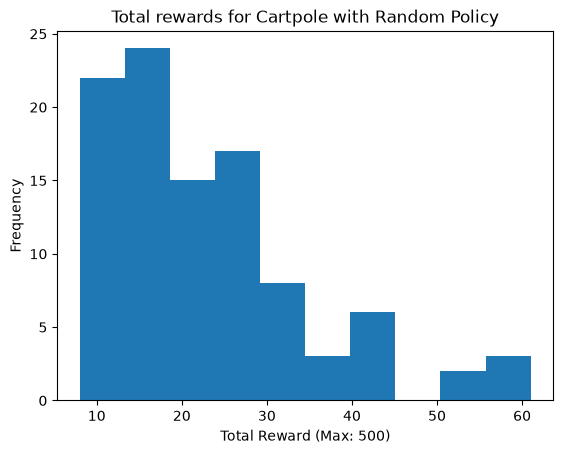

In [7]:
plt.hist(rewards)
plt.xlabel("Total Reward (Max: 500)")
plt.ylabel("Frequency")
plt.title("Total rewards for Cartpole with Random Policy")